# Week 4: Group comparison and evaluation (Group + Individual)

In Week 4, you will return to group work to compare different approaches and evaluate their performance.

## Objective

The aims of this stage are to:
- compare estimation and control strategies across the group,
- assess robustness and generalisation,
- develop a critical understanding of the strengths and limitations of different approaches.

## Group tasks

As a group, you should:
1. **Compare approaches**  
   Discuss differences in:
   - estimation methods,
   - control strategies,
   - design assumptions,
   - evaluation criteria.

2. **Standardise testing**  
   Ensure that all group members evaluate their methods under comparable conditions (e.g. initial states, input patterns, and time horizons), so that comparisons are meaningful and fair.

3. **Test robustness**  
   Evaluate performance under:
   - increased noise,
   - different stimulation patterns,
   - variations in system behaviour,
   - parameter perturbations where appropriate.

4. **Analyse results**  
   Identify:
   - which approaches perform best,
   - under what conditions,
   - what trade-offs emerge,
   - and why differences arise.

## Deliverables

### Group presentation
**10 marks**  
**Presentation session:** Tuesday 9 June, 9–11am

Your presentation should clearly communicate:
- the overall problem setup,
- the approaches explored within the group,
- comparative results,
- robustness and limitations,
- key insights and lessons learned.

Each group member is expected to contribute to both the work and the presentation.

Presentations should:
- remain concise and visually clear,
- prioritise interpretation over large quantities of plots,
- discuss both successful and unsuccessful results honestly.

You may structure the presentation in any clear and logical way.

### Individual final report
**40 marks**  
**Due:** Friday 12 June, 4pm BST

Your final report should include:
- a description of your estimation and control approach,
- experimental design and evaluation methodology,
- results and performance analysis,
- discussion of strengths and limitations,
- reflections on alternative approaches (including those explored within your group),
- suggestions for future improvements.

The report must not exceed **10 pages total**, including figures and appendix material.  
A report length of approximately **8 pages** is recommended.

Reports should be concise, well structured, and focused on reasoning and evaluation rather than exhaustive presentation of results.

Strong evaluations include both successful results and meaningful failure cases.

---

## Control interface

To make closed-loop testing consistent, your controller should follow the interface below.

Your function should take:
- the observations collected so far,
- a description of the target behaviour,

and return the next input vector \(u(t)\) to apply to the system.

You are free to implement any control strategy internally, but the function must return a command vector of the correct shape.

In [40]:
from GG4 import Brain
import numpy as np
from scipy.optimize import minimize
import scipy.linalg as la
from system_id import extract_full_orthogonal_model
N_DOMINANT = 2
N_HIDDEN = 2
N_SAMPLES_PER_TRIAL = 400
NUM_TRIALS = 4

In [25]:
def control_policy(observations, target):
    """
    Placeholder for your own control strategy.

    Parameters
    ----------
    observations : list or array
        Past observed outputs.
    target : array
        Your chosen target description.

    Returns
    -------
    u : array of shape (U,)
        Command vector to apply at the next time step.
    """
    raise NotImplementedError("Implement your control strategy here.")

Get System Matrices:

In [26]:
brain = Brain(random_seed = 1)
lds, vaf = extract_full_orthogonal_model(
    brain = brain,
    n_dominant=N_DOMINANT,
    n_hidden=N_HIDDEN,
    n_samples_per_trial=N_SAMPLES_PER_TRIAL,
    num_trials=NUM_TRIALS,
    verbose=True
)

A, B, C   = lds.A, lds.B, lds.C


████████████████████████████████████████████████████████████
INITIATING MASTER ORTHOGONAL PIPELINE (4 STATES)
████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════
STAGE 1: EXTRACTING 2 DOMINANT STATES
════════════════════════════════════════════════════════════
Step 1: Data collection
  Settling (200 steps) at baseline 0.5...

Step 2: Selecting latent dimension
  Forced LatentDim = 2 (User overridden)

Step 3: Selecting num_lags
  Selected num_lags  = 5

Step 4: N4SID + EM identification
  [1/2] N4SID initialisation...
  [info] Shapes: A=(2, 2), B=(2, 2), C=(16, 2), Q=(2, 2), R=(16, 16), Y=(256, 16), U=(256, 2)
  [2/2] EM refinement...
    iter   1  ll=-3857.091  Δll=+inf
    iter   2  ll=-2275.156  Δll=+1.582e+03
    iter   3  ll=-2217.784  Δll=+5.737e+01
    iter   4  ll=-2189.406  Δll=+2.838e+01
    iter   5  ll=-2174.584  Δll=+1.482e+01
    iter   6  ll=-2168.048  Δll=+6.535e+00
    iter   7  ll=-2165.415  Δll=+

MPC Implementation:

In [46]:

# ==========================================
# 1. SYSTEM MODEL PARAMETERS (PLACEHOLDERS)
# ==========================================
# Replace these with your actual system dynamics


# ==========================================
# 2. MPC TUNING PARAMETERS
# ==========================================
N = 20               # Prediction horizon (how far ahead to look)
n_outputs = C.shape[0]   # dimension of y = C @ x  (= 2, the latent output)
n_inputs  = B.shape[1]
Q = np.eye(n_outputs) * 10.0   # Weight for tracking error (higher = tighter tracking)
R = np.eye(n_inputs) * 0.1    # Weight for control effort (higher = smoother control)

# Optional: Actuator limits
U_MIN = 0
U_MAX = 1

class KalmanMPCController:

    def __init__(self, A, B, C, N=5):
        """
        Initializes the Controller with system matrices and tuning parameters.
        """
        # ---------------------------------------------------------
        # 1. SYSTEM DYNAMICS (16D State, 4D Obs)
        # ---------------------------------------------------------
        self.A = A
        self.B = B
        self.C = C
        
        self.state_dim = A.shape[0]     # Should be 16
        self.obs_dim = C.shape[0]       # Should be 4
        self.u_dim = B.shape[1]         # Command dimension
        
        # ---------------------------------------------------------
        # 2. KALMAN FILTER TUNING
        # ---------------------------------------------------------
        self.x_hat = np.zeros(self.state_dim)           # Initial state estimate
        self.P = np.eye(self.state_dim)                 # Initial covariance estimate
        
        # Q_kf: Process noise covariance (trust in your A & B matrices)
        self.Q_kf = np.eye(self.state_dim) * 0.01       
        # R_kf: Measurement noise covariance (trust in your sensors)
        self.R_kf = np.eye(self.obs_dim) * 0.1          
        
        self.last_u = np.zeros(self.u_dim)              # Store last command for KF prediction
        
        # ---------------------------------------------------------
        # 3. MPC TUNING
        # ---------------------------------------------------------
        self.N = N                                      # Prediction horizon
        self.Q_mpc = np.eye(self.obs_dim) * 10.0        # Tracking error penalty (4x4)
        self.R_mpc = np.eye(self.u_dim) * 0.1           # Control effort penalty
        self.U_MIN = -5.0
        self.U_MAX = 5.0

    def kalman_step(self, y):
        """
        Standard Discrete-Time Linear Kalman Filter step.
        """
        # 1. Predict (using the command we issued at the previous time step)
        x_pred = self.A @ self.x_hat + self.B @ self.last_u
        P_pred = self.A @ self.P @ self.A.T + self.Q_kf
        
        # 2. Update (using the brand new observation y)
        # S = Innovation covariance
        S = self.C @ P_pred @ self.C.T + self.R_kf
        # K = Kalman Gain
        K = P_pred @ self.C.T @ np.linalg.inv(S)
        
        # Update estimate and covariance
        self.x_hat = x_pred + K @ (y - self.C @ x_pred)
        self.P = (np.eye(self.state_dim) - K @ self.C) @ P_pred

    def __call__(self, observations, target):
        """
        This method allows the class instance to be called like a function.
        Matches the interface: u = controller(observations, target)
        """
        obs_array = np.array(observations)
        
        # ---------------------------------------------------------
        # STEP 1: STATE ESTIMATION (Kalman Filter)
        # ---------------------------------------------------------
        if len(obs_array) > 0:
            # We only want to process the *latest* observation since 
            # our class maintains the state history internally.
            latest_y = obs_array[-1]
            self.kalman_step(latest_y)
        else:
            # First time step, no observations yet. 
            pass 
            
        x0 = self.x_hat.copy()

        # ---------------------------------------------------------
        # STEP 2: MODEL PREDICTIVE CONTROL
        # ---------------------------------------------------------
        def cost_function(U_sequence):
            cost = 0.0
            x_k = x0.copy()
            
            for k in range(self.N):
                u_k = U_sequence[k * self.u_dim : (k + 1) * self.u_dim]
                
                # Predict forward using internal model
                x_k = self.A @ x_k + self.B @ u_k
                y_k = self.C @ x_k
                
                # Target extraction
                if isinstance(target, np.ndarray) and target.ndim > 0 and len(target) > k:
                    ref = target[k]
                elif isinstance(target, np.ndarray) and target.ndim > 0:
                    ref = target[-1]
                else:
                    ref = target
                    
                error = y_k - ref
                cost += (error.T @ self.Q_mpc @ error) + (u_k.T @ self.R_mpc @ u_k)
                
            return cost

        # ---------------------------------------------------------
        # STEP 3: OPTIMIZATION & COMMAND EXECUTION
        # ---------------------------------------------------------
        U0 = np.zeros(self.N * self.u_dim)
        bounds = [(self.U_MIN, self.U_MAX) for _ in range(self.N * self.u_dim)]
        
        result = minimize(cost_function, U0, method='SLSQP', bounds=bounds)
        
        if result.success:
            u_next = result.x[0 : self.u_dim]
        else:
            print("Warning: MPC Optimization failed. Applying zero control.")
            u_next = np.zeros(self.u_dim)
            
        # Store command for the next Kalman Filter prediction step
        self.last_u = u_next 
        
        return u_next
    
mpc = KalmanMPCController(A, B, C, N=5)

Hpefully better MPC implementation

In [47]:
class AugmentedKalmanFilter:
    def __init__(self, A: np.ndarray, B: np.ndarray, C: np.ndarray, 
                 Q_process: np.ndarray, R_measure: np.ndarray, Q_disturbance: float = 0.01):
        self.d = A.shape[0]
        self.m = B.shape[1]
        self.N = C.shape[0]
        
        self.A_aug = np.block([
            [A, np.zeros((self.d, self.N))],
            [np.zeros((self.N, self.d)), np.eye(self.N)]
        ])
        
        self.B_aug = np.vstack([B, np.zeros((self.N, self.m))])
        self.C_aug = np.hstack([C, np.eye(self.N)])
        
        Q_d = np.eye(self.N) * Q_disturbance
        self.Q_aug = la.block_diag(Q_process, Q_d)
        
        P_prior = la.solve_discrete_are(self.A_aug.T, self.C_aug.T, self.Q_aug, R_measure)
        S = self.C_aug @ P_prior @ self.C_aug.T + R_measure
        self.L_aug = P_prior @ self.C_aug.T @ la.inv(S)
        
        self.x_aug = np.zeros((self.d + self.N, 1))

    def update(self, y_k: float, u_prev: float) -> tuple[np.ndarray, np.ndarray]:
        y_k = np.array(y_k).reshape(-1, 1)
        u_prev = np.array(u_prev).reshape(-1, 1)
        
        y_pred = self.C_aug @ self.x_aug
        self.x_aug = self.x_aug + self.L_aug @ (y_k - y_pred)
        
        x_est = self.x_aug[:self.d]
        d_est = self.x_aug[self.d:]
        
        self.x_aug = self.A_aug @ self.x_aug + self.B_aug @ u_prev
        
        return x_est, d_est

class ConstrainedMPC:
    def __init__(self, A, B, C, horizon, Q_cost, R_cost):
        self.A = A
        self.B = B
        self.C = C
        self.horizon = horizon
        self.N = horizon
        self.Q = Q_cost  
        self.R = R_cost  
        
        self.d = A.shape[0]
        self.m = B.shape[1]
        
        self.u_guess = np.zeros(self.N * self.m)

    def get_input(self, x_current, target_trajectory_window):
        def cost_function(u_flat):
            u_seq = u_flat.reshape(self.horizon, self.m)
            cost = 0
            x = x_current.copy().reshape(-1, 1)
            
            for i in range(self.horizon):
                u_i = u_seq[i].reshape(-1, 1)
                x = self.A @ x + self.B @ u_i
                y_pred = self.C @ x
                
                y_ref = target_trajectory_window[i].reshape(-1, 1)
                error = y_pred - y_ref
                
                cost += (error.T @ self.Q @ error)[0, 0]
                cost += (u_i.T @ self.R @ u_i)[0, 0]
                
            return cost

        bounds = [(0.0, 1.0) for _ in range(self.horizon * self.m)]
        
        result = minimize(
            cost_function, 
            self.u_guess, 
            bounds=bounds, 
            method='L-BFGS-B',
            options={'ftol': 1e-6, 'disp': False} 
        )
        
        optimal_u_seq = result.x.reshape(self.N, self.m)
        self.u_guess[:-self.m] = result.x[self.m:]
        self.u_guess[-self.m:] = optimal_u_seq[-1] 
        
        return optimal_u_seq[0]

# ==========================================
# 2. THE WRAPPER (Bridges your classes to the test loop)
# ==========================================
class IntegratedController:
    def __init__(self, estimator, controller_algo):
        self.estimator = estimator
        self.controller = controller_algo
        self.u_prev = np.zeros(self.estimator.m)
        
    def __call__(self, observations, target):
        t = len(observations)
        
        # 1. Update Estimator
        if t > 0:
            y_k = observations[-1]
            x_est, d_est = self.estimator.update(y_k, self.u_prev)
        else:
            x_est = np.zeros(self.estimator.d)
            
        # 2. Slice Target Window
        horizon = getattr(self.controller, 'horizon', 1) 
        window = []
        for i in range(horizon):
            idx = t + i
            if isinstance(target, np.ndarray) and target.ndim > 0:
                if idx < len(target):
                    window.append(target[idx])
                else:
                    window.append(target[-1]) 
            else:
                window.append(target)
                
        target_window = np.array(window)
        
        # 3. Get Control Input
        u_next = self.controller.get_input(x_est, target_window)
        self.u_prev = u_next 
        
        return u_next

In [48]:
estimator = AugmentedKalmanFilter(
     A, B, C, 
     Q_process=np.eye(A.shape[0]) * 0.01, 
     R_measure=np.eye(C.shape[0]) * 0.1
 )

mpc = ConstrainedMPC(
     A, B, C, 
     horizon=10, 
     Q_cost=np.eye(C.shape[0]) * 10.0, 
     R_cost=np.eye(B.shape[1]) * 0.1
 )

my_controller = IntegratedController(estimator, mpc)

## Running a closed-loop experiment

The following helper function illustrates how to run the simulator in closed loop.

At each time step:

1. the current observation is measured,

2. the controller generates an input based on past observations,

3. the input is applied to the system,

4. the resulting observations and commands are stored.

This provides a simple framework for testing and comparing different control strategies.

In [28]:
def run_closed_loop(brain_factory, controller, target, T=100):
    """
    Run the simulator in closed loop using a user-defined controller.
    """
    brain = brain_factory()
    observations = []
    commands = []

    for _ in range(T):
        y = brain.measure()
        u = controller(np.array(observations), target)
        brain.next_state(u)

        observations.append(y)
        commands.append(u)

    return np.vstack(observations), np.vstack(commands)

## Standardising experiments

The following wrapper provides a simple standard interface for running experiments.

When comparing approaches within your group, you should aim to use:
- the same experimental duration,
- the same target definitions,
- and comparable initial conditions where possible.

Standardising evaluation conditions makes comparisons more meaningful and easier to interpret.

In [29]:
def run_experiment(brain_factory, controller, target, T=100):
    """
    Standard wrapper for comparing controllers under shared conditions.
    Groups should use the SAME test conditions when comparing approaches.
    """
    observations, commands = run_closed_loop(brain_factory, controller, target, T=T)
    return observations, commands

In [30]:
import numpy as np

def evaluate_trajectories(
    brain_factory, 
    controller, 
    targets_dict: dict[str, np.ndarray], 
    T: int = 100
) -> dict[str, dict]:
    """
    Evaluates a controller across a suite of different target trajectories.
    
    Parameters:
    -----------
    brain_factory : callable
        Function or class to instantiate a fresh brain environment.
    controller : object
        The closed-loop controller being evaluated (e.g., LQR, MPC).
    targets_dict : dict
        Dictionary mapping trajectory names to target arrays.
    T : int
        Simulation steps per trajectory.
        
    Returns:
    --------
    results : dict
        Nested dictionary containing observations, commands, and RMSE per trajectory.
    """
    results = {}
    
    print("\n" + "═" * 60)
    print(f"CONTROLLER EVALUATION SUITE ({len(targets_dict)} Trajectories)")
    print("═" * 60)
    
    average_rmse = 0.0
    
    for name, target in targets_dict.items():
        # 1. Run the simulation
        obs, cmds = run_experiment(brain_factory, controller, target, T=T)
        
        # 2. Calculate Tracking Error (RMSE)
        # Handle both constant setpoints (1D) and time-varying trajectories (2D)
        if isinstance(target, np.ndarray) and target.ndim > 1:
            t_len = min(len(obs), len(target))
            error = obs[:t_len] - target[:t_len]
        else:
            error = obs - target
            
        rmse = float(np.sqrt(np.mean(error**2)))
        average_rmse += rmse
        
        # 3. Store the full telemetry
        results[name] = {
            "observations": obs,
            "commands": cmds,
            "rmse": rmse
        }
        
        print(f"  {name:<20} | Tracking RMSE: {rmse:.4f}")
        
    print("-" * 60)
    print(f"  Average Global RMSE  | {average_rmse / len(targets_dict):.4f}")
    print("═" * 60 + "\n")
    
    return results

Generate standard trajectories

In [31]:
import numpy as np

def generate_standard_trajectories(T=100, dim=1):
    """
    Generates a dictionary of standard test trajectories for evaluation.
    
    Parameters:
    -----------
    T : int
        Number of time steps.
    dim : int
        Dimensionality of the target (e.g., 1 for single-output, 2 for X-Y tracking).
        
    Returns:
    --------
    dict mapping trajectory names to target arrays.
    """
    t = np.arange(T)
    trajectories = {}
    
    for d in range(dim):
        # 1. Step response (constant setpoint of 5.0)
        step = np.ones(T) * 5.0
        
        # 2. Sine Wave (oscillatory tracking)
        sine = 5.0 * np.sin(2 * np.pi * t / (T / 2))
        
        # 3. Ramp (constant velocity)
        ramp = 0.1 * t
        
        # 4. Square Wave (abrupt changes)
        square = 5.0 * np.sign(np.sin(2 * np.pi * t / (T / 2)))
        
        if dim == 1:
            trajectories = {
                "Step": step, "Sine": sine, "Ramp": ramp, "Square": square
            }
        else:
            # Stack dynamically for multi-dimensional targets
            trajectories["Step"] = np.column_stack((trajectories.get("Step", np.empty((T, 0))), step))
            trajectories["Sine"] = np.column_stack((trajectories.get("Sine", np.empty((T, 0))), sine))
            trajectories["Ramp"] = np.column_stack((trajectories.get("Ramp", np.empty((T, 0))), ramp))
            trajectories["Square"] = np.column_stack((trajectories.get("Square", np.empty((T, 0))), square))
            
    return trajectories

Test controller

In [34]:
def evaluate_and_store_performance(brain_factory, controller, T=100, target_dim=1):
    """
    Generates trajectories, evaluates the controller on them, 
    and returns both the performance results and the stored trajectories.
    
    Parameters:
    -----------
    brain_factory : callable
        Function to instantiate the system (e.g., lambda: Brain()).
    controller : callable
        The control policy function.
    T : int
        Time horizon for the simulation.
    target_dim : int
        Number of target dimensions required by the system.
        
    Returns:
    --------
    results : dict
        Contains observations, commands, and metrics for each trajectory.
    trajectories : dict
        The generated targets used for the evaluation.
    """
    # 1. Generate and store trajectories
    trajectories = generate_standard_trajectories(T=T, dim=target_dim)
    results = {}
    
    print(f"{'='*60}\nCONTROLLER EVALUATION SUITE\n{'='*60}")
    
    avg_rmse = 0.0
    
    for name, target in trajectories.items():
        # 2. Run the closed-loop experiment (using your existing function)
        obs, cmds = run_experiment(brain_factory, controller, target, T=T)
        
        # 3. Calculate Error Metrics
        # Slice to ensure dimensions match in case simulation stopped early
        t_len = min(len(obs), len(target))
        obs_trimmed = np.array(obs)[:t_len]
        target_trimmed = np.array(target)[:t_len]
        
        # Reshape to 1D if necessary to ensure broadcasting works correctly
        error = obs_trimmed.reshape(t_len, -1) - target_trimmed.reshape(t_len, -1)
        
        rmse = float(np.sqrt(np.mean(error**2)))
        max_dev = float(np.max(np.abs(error)))
        
        avg_rmse += rmse
        
        # 4. Store telemetry and metrics
        results[name] = {
            "observations": obs,
            "commands": cmds,
            "rmse": rmse,
            "max_deviation": max_dev
        }
        
        print(f"  {name:<10} | RMSE: {rmse:.4f} | Max Deviation: {max_dev:.4f}")
        
    print(f"{'-'*60}\n  Overall Average RMSE: {avg_rmse / len(trajectories):.4f}\n{'='*60}")
    
    return results, trajectories

import matplotlib.pyplot as plt

def plot_evaluation_results(results, trajectories):
    """
    Plots the observations, targets, and control commands for each trajectory.
    
    Parameters:
    -----------
    results : dict
        The output dictionary from evaluate_and_store_performance containing observations and commands.
    trajectories : dict
        The dictionary of target trajectories used for the evaluation.
    """
    num_trajectories = len(results)
    
    if num_trajectories == 0:
        print("No results to plot.")
        return
        
    # Create a figure with 2 columns (Tracking and Control) and rows = number of trajectories
    fig, axes = plt.subplots(nrows=num_trajectories, ncols=2, figsize=(14, 4 * num_trajectories))
    
    # Handle the case of a single trajectory (subplots returns 1D array instead of 2D)
    if num_trajectories == 1:
        axes = [axes]
        
    for i, (name, target) in enumerate(trajectories.items()):
        if name not in results:
            continue
            
        obs = np.array(results[name]["observations"])
        cmds = np.array(results[name]["commands"])
        rmse = results[name].get("rmse", 0.0)
        
        t_len = min(len(obs), len(target))
        t = np.arange(t_len)
        
        ax_track = axes[i][0]
        ax_cmd = axes[i][1]
        
        # --- 1. Plot Tracking Performance ---
        # Assuming the target and the primary observation are aligned on the first dimension.
        # If your observations are multi-dimensional, this plots the first dimension.
        if obs.ndim > 1:
            ax_track.plot(t, obs[:t_len, 0], label="Observation (Dim 0)", color="blue", linewidth=2)
            # You can add more lines here if you want to see other observation dimensions:
            # ax_track.plot(t, obs[:t_len, 1], label="Observation (Dim 1)", alpha=0.5)
        else:
            ax_track.plot(t, obs[:t_len], label="Observation", color="blue", linewidth=2)
            
        # Plot Target
        if isinstance(target, np.ndarray) and target.ndim > 1:
            ax_track.plot(t, target[:t_len, 0], 'r--', label="Target", linewidth=2)
        else:
            ax_track.plot(t, target[:t_len], 'r--', label="Target", linewidth=2)
            
        ax_track.set_title(f"{name} Trajectory Tracking (RMSE: {rmse:.3f})")
        ax_track.set_xlabel("Time Step")
        ax_track.set_ylabel("System Output")
        ax_track.legend()
        ax_track.grid(True, alpha=0.3)
        
        # --- 2. Plot Control Commands ---
        if cmds.ndim > 1:
            for d in range(cmds.shape[1]):
                ax_cmd.plot(t, cmds[:t_len, d], label=f"Command Dim {d}")
        else:
            ax_cmd.plot(t, cmds[:t_len], label="Control Command", color="purple")
            
        ax_cmd.set_title(f"{name} Control Effort")
        ax_cmd.set_xlabel("Time Step")
        ax_cmd.set_ylabel("Input Amplitude")
        ax_cmd.legend()
        ax_cmd.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

In [42]:
results, stored_trajectories = evaluate_and_store_performance(
    brain_factory=lambda: Brain(random_seed = 3), 
     controller=my_controller, 
     T=1000, 
     target_dim=1
 )

CONTROLLER EVALUATION SUITE


C:\Users\hassa\AppData\Local\Temp\ipykernel_2792\3772156023.py:75: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


  Step       | RMSE: 1.3922 | Max Deviation: 6.8696
  Sine       | RMSE: 2.7977 | Max Deviation: 8.6054
  Ramp       | RMSE: 49.6463 | Max Deviation: 95.0471
  Square     | RMSE: 3.8926 | Max Deviation: 9.7081
------------------------------------------------------------
  Overall Average RMSE: 14.4322


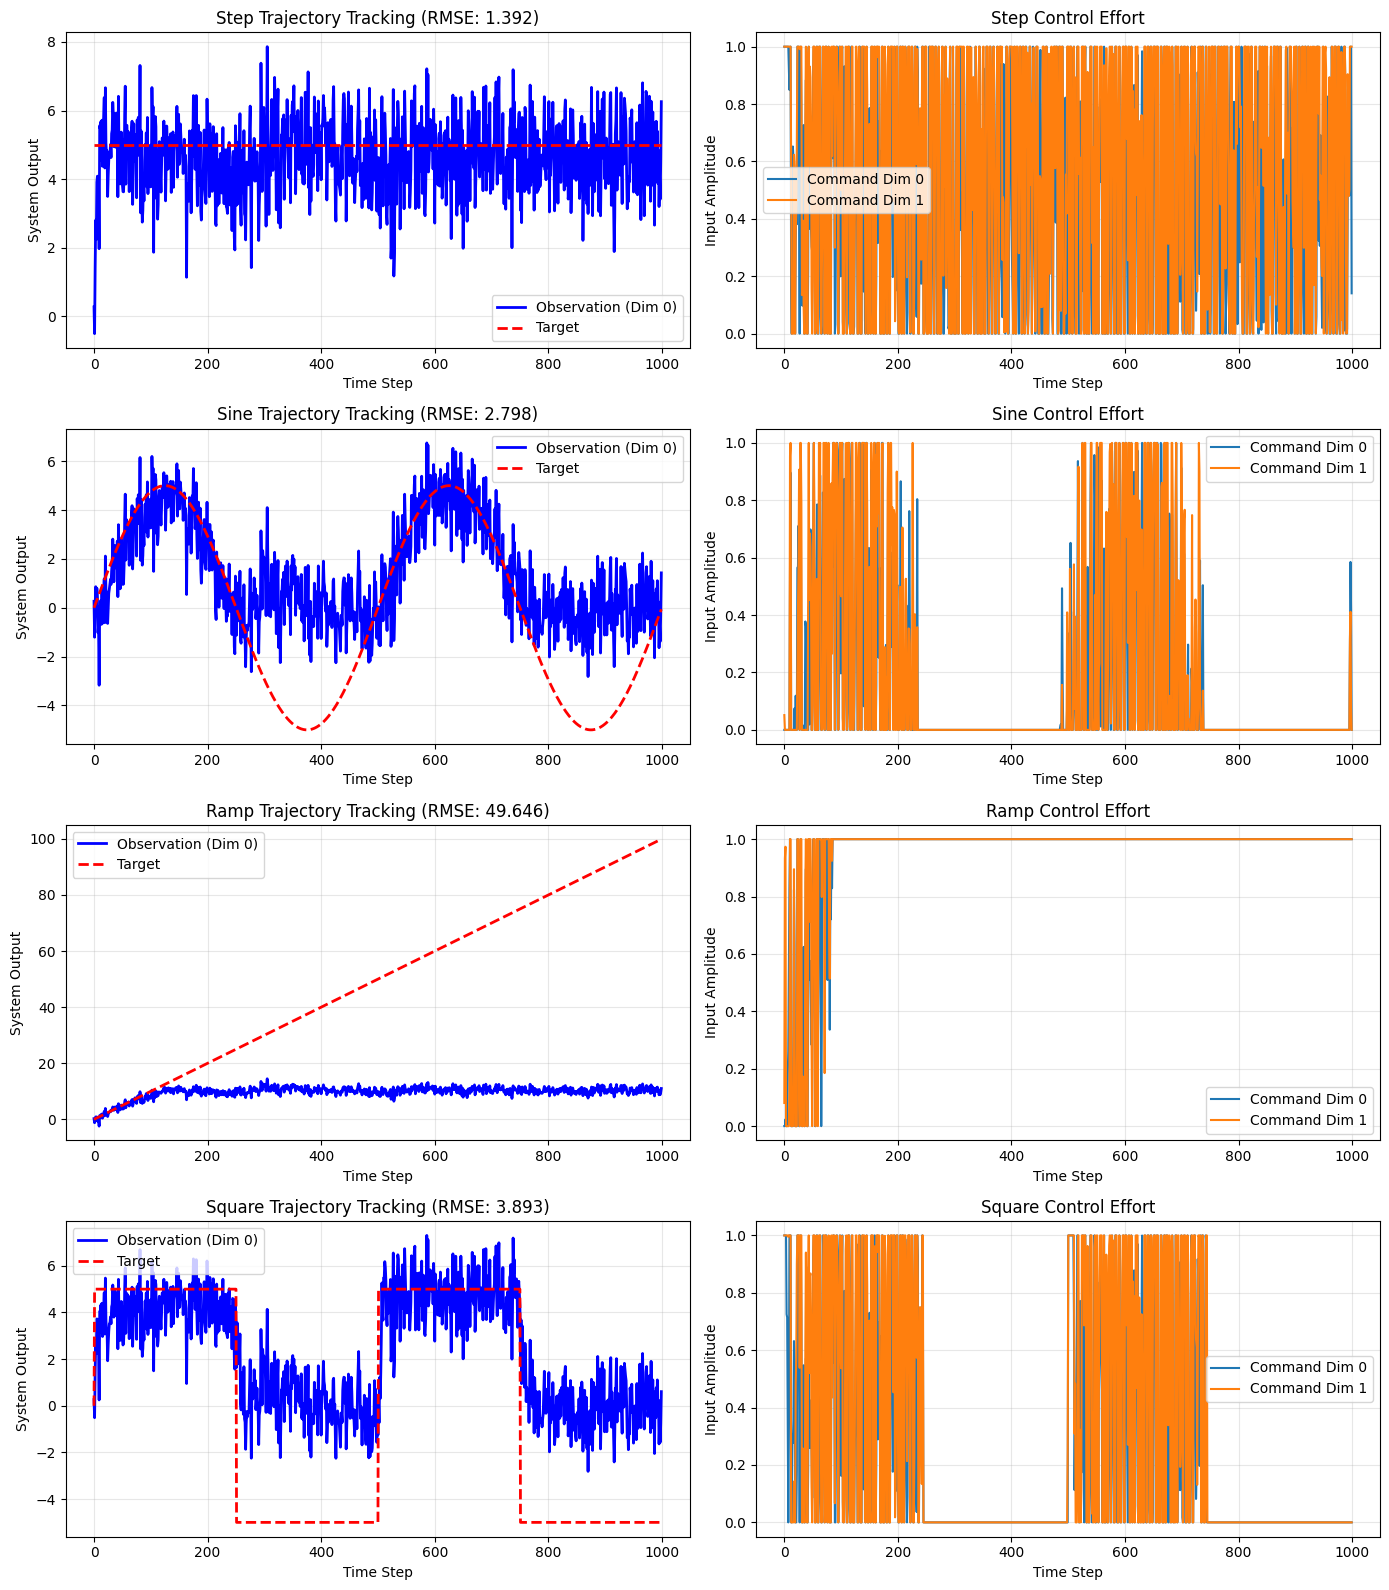

In [43]:
plot_evaluation_results(results, stored_trajectories)

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def evaluate_frequency_response(
    brain_factory, 
    controller, 
    frequencies: list, 
    amplitude: float = 5.0, 
    T: int = 500, 
    dt: float = 1.0,
    target_dim: int = 0
):
    """
    Tests a controller across an array of sine waves to measure frequency lock
    (Magnitude Squared Coherence) and phase lag (Cross-Correlation).
    
    Parameters:
    -----------
    brain_factory : callable
        Factory function for the simulation environment.
    controller : callable
        The integrated controller / control policy.
    frequencies : list of floats
        The frequencies (in Hz or cycles/step) to test.
    amplitude : float
        The amplitude of the sine waves.
    T : int
        Number of simulation steps per frequency test. 
        (Keep T reasonably large, e.g., >250, for good FFT resolution).
    dt : float
        Time step duration.
    target_dim : int
        Which dimension of the observation space to evaluate against.
    """
    results = {}
    fs = 1.0 / dt # Sampling frequency
    
    # Tuning parameter for Welch's method in Coherence calculation
    # We want a window small enough to fit in T, but large enough for resolution
    nperseg = min(256, T // 2) 
    
    for freq in frequencies:
        # 1. Generate the target sine wave array
        t_arr = np.arange(T) * dt
        
        # If your controller expects a multi-dimensional target, we map the sine wave 
        # to the primary dimension and leave others as 0.
        target_traj = np.zeros((T, getattr(controller.estimator, 'N', 1)))
        sine_wave = amplitude * np.sin(2 * np.pi * freq * t_arr) + amplitude
        target_traj[:, target_dim] = sine_wave
        
        # 2. Run the closed-loop simulation
        obs, cmds = run_experiment(brain_factory, controller, target_traj, T=T)
        
        # Extract the actual output dimension we care about
        y_out = np.array(obs)[:T, target_dim]
        y_ref = target_traj[:T, target_dim]
        
        # -------------------------------------------------------------
        # 3. Magnitude Squared Coherence (Frequency Domain)
        # -------------------------------------------------------------
        f_coh, Cxy = signal.coherence(y_ref, y_out, fs=fs, nperseg=nperseg)
        
        # Find the coherence score exactly at our driving frequency
        # (Find the closest frequency bin in the FFT output)
        idx_f = np.argmin(np.abs(f_coh - freq))
        coherence_score = Cxy[idx_f]
        
        # -------------------------------------------------------------
        # 4. Cross-Correlation (Time Domain Phase Lag)
        # -------------------------------------------------------------
        # Subtract mean to compute normalized covariance, avoiding edge-effect bias
        y_out_centered = y_out - np.mean(y_out)
        y_ref_centered = y_ref - np.mean(y_ref)
        
        correlation = signal.correlate(y_out_centered, y_ref_centered, mode='full')
        lags = signal.correlation_lags(len(y_out), len(y_ref), mode='full')
        
        # Find the time shift (lag) that maximizes the correlation
        best_lag_idx = np.argmax(correlation)
        time_delay_steps = lags[best_lag_idx]
        
        # Convert step delay to phase lag in degrees: (delay / period) * 360
        period_steps = 1.0 / (freq * dt)
        phase_lag_deg = (time_delay_steps / period_steps) * 360.0
        
        # Store metrics
        results[freq] = {
            "coherence": coherence_score,
            "delay_steps": time_delay_steps,
            "phase_lag_deg": phase_lag_deg,
            "obs": y_out,
            "ref": y_ref
        }
        
        print(f"Freq: {freq:.3f} Hz | Coherence: {coherence_score:.4f} | Delay: {time_delay_steps} steps ({phase_lag_deg:.1f}°)")

    # -------------------------------------------------------------
    # 5. Plotting the Bode-style Response
    # -------------------------------------------------------------
    freqs = list(results.keys())
    coherences = [results[f]["coherence"] for f in freqs]
    phase_lags = [results[f]["phase_lag_deg"] for f in freqs]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Coherence Plot
    ax1.plot(freqs, coherences, marker='o', color='b', linestyle='-', linewidth=2)
    ax1.set_ylabel('Magnitude Sq Coherence')
    ax1.set_title('Controller Frequency Response')
    ax1.set_ylim([0, 1.05])
    ax1.axhline(0.707, color='r', linestyle='--', alpha=0.5, label='-3dB Equivalent limit')
    ax1.legend()
    ax1.grid(True, which="both", ls="-", alpha=0.3)
    
    # Phase Lag Plot
    ax2.plot(freqs, phase_lags, marker='s', color='g', linestyle='-', linewidth=2)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Phase Lag (Degrees)')
    ax2.grid(True, which="both", ls="-", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

C:\Users\hassa\AppData\Local\Temp\ipykernel_2792\3772156023.py:75: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Freq: 0.010 Hz | Coherence: 0.2811 | Delay: 5 steps (18.0°)
Freq: 0.031 Hz | Coherence: 0.8483 | Delay: 6 steps (67.2°)
Freq: 0.052 Hz | Coherence: 0.6445 | Delay: 99 steps (1861.2°)
Freq: 0.073 Hz | Coherence: 0.8318 | Delay: -78 steps (-2059.2°)
Freq: 0.094 Hz | Coherence: 0.1057 | Delay: -186 steps (-6324.0°)
Freq: 0.116 Hz | Coherence: 0.7378 | Delay: -94 steps (-3910.4°)
Freq: 0.137 Hz | Coherence: 0.0914 | Delay: -180 steps (-8856.0°)
Freq: 0.158 Hz | Coherence: 0.8565 | Delay: -24 steps (-1363.2°)
Freq: 0.179 Hz | Coherence: 0.7907 | Delay: -59 steps (-3799.6°)
Freq: 0.200 Hz | Coherence: 0.5855 | Delay: -43 steps (-3096.0°)


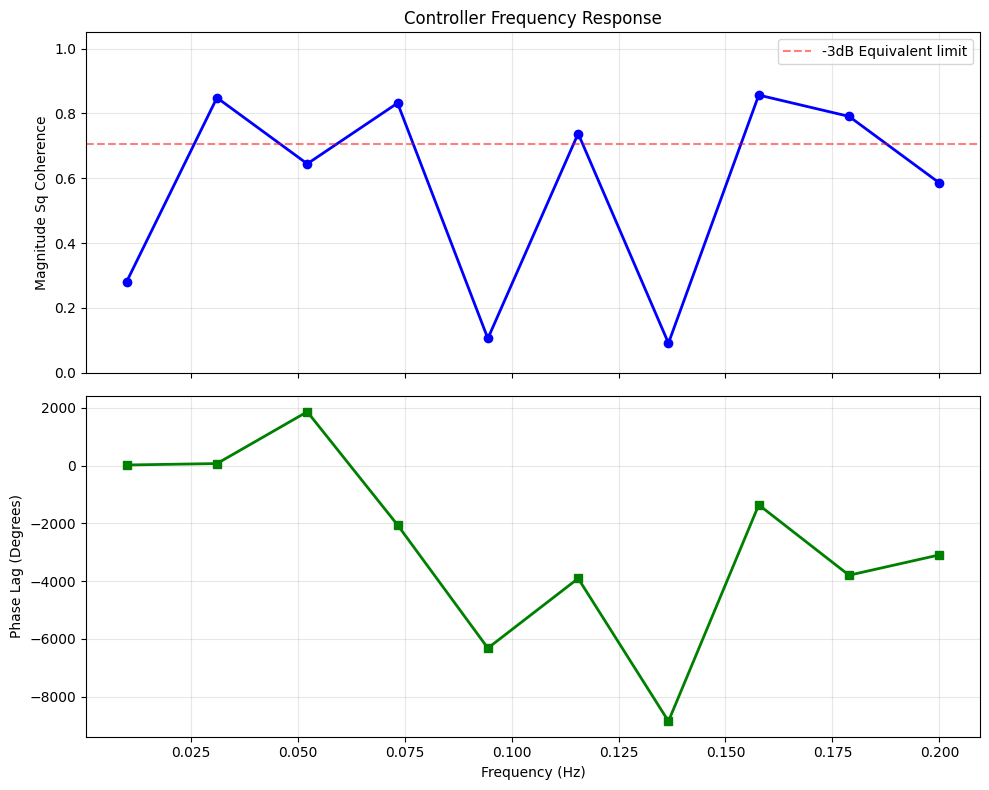

In [49]:
# Create an array of frequencies from very slow to moderately fast
# e.g., 10 frequencies between 0.01 Hz and 0.2 Hz
test_freqs = np.linspace(0.01, 0.2, 10)

# Make sure to give it enough time steps (T) so that the lowest frequency 
# can complete at least a couple of full periods! 
# (e.g., 0.01 Hz has a period of 100 steps, so T=500 is good).

freq_results = evaluate_frequency_response(
    brain_factory=lambda: Brain(random_seed=3),
    controller=my_controller, # From the wrapper we built earlier
    frequencies=test_freqs,
    amplitude=5.0,
    T=500,  
    target_dim=0 
)

---
## Final remarks

The final stage of the project is not only about achieving good performance, but also about demonstrating understanding.

Strong submissions will demonstrate:
- clear engineering reasoning,
- careful experimental design,
- thoughtful evaluation,
- critical assessment of both successes and limitations,
- and well-structured technical communication.

Complexity alone is not rewarded. Carefully justified and thoroughly analysed approaches are preferable to complicated but poorly understood methods.
